In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath, sep=',')
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    return df

def filter_noise(df, threshold=0.001):
    clean = df[df['pnl'].abs() >= threshold]
    noise = df[df['pnl'].abs() < threshold]
    return clean, noise

def compute_info(clean):
    wins = clean[clean['pnl'] > 0]
    losses = clean[clean['pnl'] < 0]
    win_rate = 100 * len(wins) / len(clean)
    avg_win = wins['pnl'].mean()
    avg_loss = losses['pnl'].mean()
    ev = (len(wins)/len(clean) * avg_win + (len(losses)/len(clean)) * avg_loss)
    return win_rate, avg_win, avg_loss, ev

def plot_equity_curve(df):
    df = df.copy()
    df['fee'] = 0.001 * 0.001 * (df['entry_price'] + df['exit_price'])
    df['cumulative_fees'] = df['fee'].cumsum()
    df['net_pnl'] = df['total_pnl'] - df['cumulative_fees']
    plt.plot(df['timestamp'], df['total_pnl'], label='no fees')
    plt.plot(df['timestamp'], df['net_pnl'], label='with fees', linestyle='--')
    plt.xlabel('time')
    plt.ylabel('cumulative pnl')
    plt.title('equity curve')
    plt.legend()
    plt.show()
    
def plot_pnl_distribution(clean):
    bars = int(math.sqrt(len(clean)))
    plt.hist(clean['pnl'], bars)
    plt.xlabel('pnl per trade')
    plt.ylabel('frequency')
    plt.title('pnl distribution')
    plt.show()

def run_binomial_test(wins, clean):
    res = stats.binomtest(len(wins), len(clean), 0.5, alternative='greater')
    return res.pvalue

def run_ttest(clean):
    t_stat, p_value = stats.ttest_1samp(clean['pnl'], 0)
    return t_stat, p_value

def compute_sharpe_ratio(df):
    return df['pnl'].mean() / df['pnl'].std()

def compute_max_drawdown(df):
    peak = df['total_pnl'].cummax()
    drawdown = df['total_pnl'] - peak
    return min(drawdown)
    
def analyse(df, session_id):
    print(f"session {session_id}")
    session = df[df['session_id'] == session_id]
    clean, noise = filter_noise(session)
    win_rate, avg_win, avg_loss, ev = compute_info(clean)
    wins = clean[clean['pnl'] > 0]
    t_stat, p_value = run_ttest(clean)

    print(f"total trades: {len(session)}")
    print(f"clean trades: {len(clean)}")
    print(f"noisy trades: {len(noise)} ({100*len(noise)/len(session):.1f}%)")
    print(f"win rate: {win_rate:.1f}%")
    print(f"avg win: {avg_win:.4f}")
    print(f"avg loss: {avg_loss:.4f}")
    print(f"ev: {ev:.4f}")
    print(f"sharpe ratio (clean): {compute_sharpe_ratio(clean):.4f}")
    print(f"sharpe ratio (all trades): {compute_sharpe_ratio(session):.4f}")
    print(f"max drawdown: {compute_max_drawdown(session):.4f}")
    print(f"binomial p-value: {run_binomial_test(wins, clean):.2e}")
    print(f"t-test t-statistic: {t_stat:.4f}")
    print(f"t-test p-value: {p_value:.2e}")
    plot_equity_curve(session)
    plot_pnl_distribution(clean)

session 1
total trades: 1935
clean trades: 1397
noisy trades: 538 (27.8%)
win rate: 88.8%
avg win: 0.0146
avg loss: -0.0063
ev: 0.0122
sharpe ratio (clean): 0.7982
sharpe ratio (all trades): 0.6255
max drawdown: -0.0415
binomial p-value: 1.94e-209
t-test t-statistic: 29.8346
t-test p-value: 1.04e-151


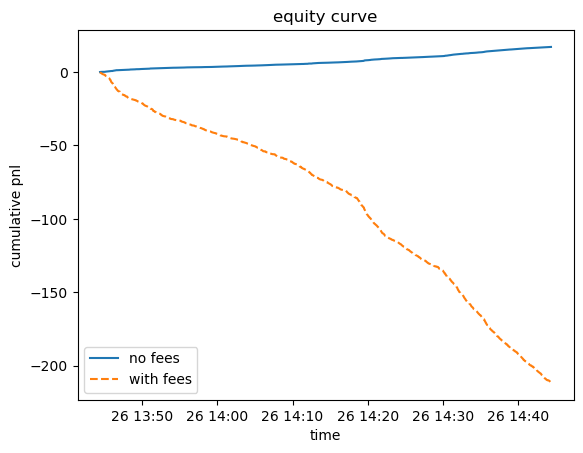

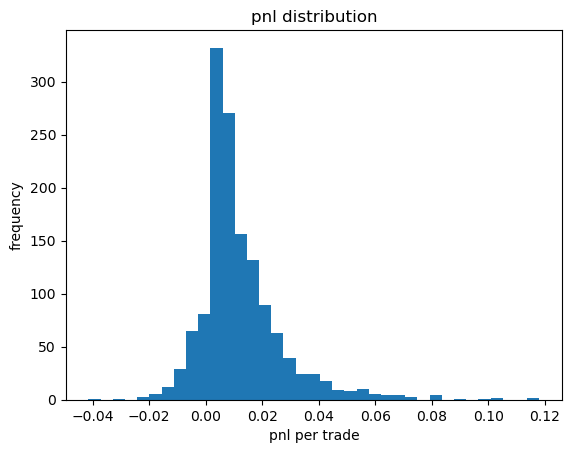

session 2
total trades: 569
clean trades: 398
noisy trades: 171 (30.1%)
win rate: 90.5%
avg win: 0.0148
avg loss: -0.0048
ev: 0.0129
sharpe ratio (clean): 0.9216
sharpe ratio (all trades): 0.6891
max drawdown: -0.0399
binomial p-value: 3.33e-67
t-test t-statistic: 18.3863
t-test p-value: 4.62e-55


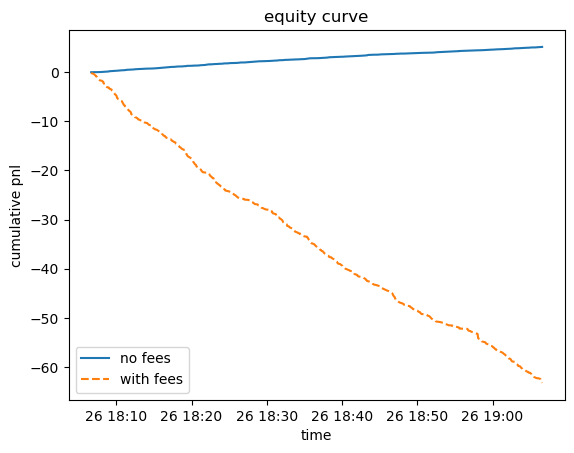

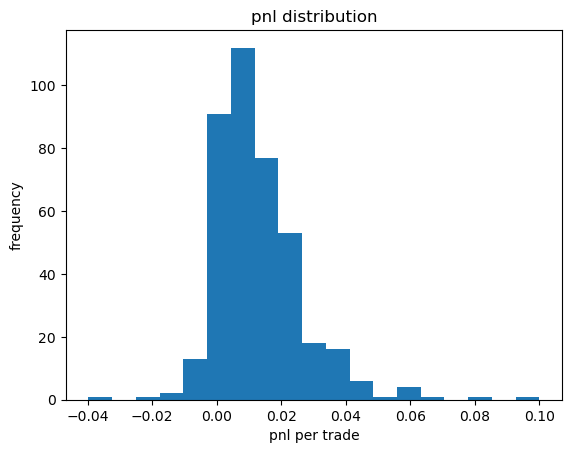

In [3]:
df = load_data('trades.csv')
analyse(df, 1)
analyse(df, 2)